# pct_ladder Strategy Backtester
Configure parameters below, then **Run All** (`Kernel → Restart & Run All`).

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from decimal import Decimal
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('Imports OK')

Imports OK


## ⚙️ Configuration

In [2]:
# START_DATE  = '2022-01-01'
# END_DATE    = '2026-01-01'
START_DATE  = '2026-01-01'
END_DATE    = '2026-04-10'
INTERVAL    = '1m'

INITIAL_CASH      = 35_000
INITIAL_ETH       = 5.0
INITIAL_ETH_COST  = 3_000

UPPER_PCT   = 0.4
LOWER_PCT   = 0.4
BUY_QUOTE   = 3200
SELL_QUOTE  = 3200
QTY_STEP    = 1e-6
MIN_QTY     = 1e-6

# Sizing mode: 'fixed_quote' | 'banded_qty'
# banded_qty: qty = BUY_QUOTE / band_mid,  band_mid = floor(price/BAND_WIDTH)*BAND_WIDTH + BAND_WIDTH/2
SIZING_MODE = 'banded_qty'   # change to 'fixed_quote' to revert
BAND_WIDTH  = 100            # price band width for banded_qty (ignored for fixed_quote)

REBALANCE_THRESHOLD_STEPS = 2
REBALANCE_TARGET_STEPS    = 3

# Compounding: resize buy_quote each interval to keep it at the same % of equity.
# None = disabled | 'daily' | 'weekly' | 'monthly'
COMPOUND_INTERVAL = 'daily'

# Cap on buy_quote during compounding — prevents runaway over long backtests.
# Set to 0 to disable (unlimited). Realistic live max ≈ 2-3× starting quote.
MAX_BUY_QUOTE = 10_000   # e.g. 10_000 = cap at $10K per trade

QUOTE_RESERVE        = 500
USE_INVENTORY_BUFFER = True

SYMBOL       = 'ETHUSDC'
FETCH_SYMBOL = 'ETHUSDT'
DATA_SOURCE  = 'binance'
CACHE_DIR    = 'cache'

# Config comparison uses a coarser interval for speed (1h = ~35k candles vs 2.1M for 1m)
COMPARE_INTERVAL = '1m'   # '1m' for full accuracy | '1h' for fast comparison

# Intra-candle price path simulation mode:
#   'random'      — randomly assign low-first or high-first per candle (unbiased, seeded=42)
#   'optimistic'  — bullish candles always go low→high (best case for grid, OLD behavior)
#   'pessimistic' — bullish candles always go high→low (worst case for grid)
# Use 'random' for primary analysis. Compare optimistic vs pessimistic to see the range.
PRICE_PATH_MODE = 'random'

## 📥 Fetch Historical Data

In [3]:
from backtest.fetch_data import fetch_klines, dt_to_ms

df_candles = fetch_klines(
    symbol=FETCH_SYMBOL, interval=INTERVAL,
    start_ms=dt_to_ms(START_DATE), end_ms=dt_to_ms(END_DATE),
    cache_dir=CACHE_DIR, source=DATA_SOURCE,
)
candles = df_candles.to_dict('records')
days    = (pd.Timestamp(END_DATE) - pd.Timestamp(START_DATE)).days
print(f'Loaded {len(df_candles):,} candles  |  {df_candles["ts"].iloc[0]}  ->  {df_candles["ts"].iloc[-1]}')
df_candles.tail(3)

[fetch_data] Fetching ETHUSDT 1m from BINANCE (~142,560 candles, ~143 requests)...
[fetch_data]   35.1% — 50,000 candles fetched...
[fetch_data]   70.1% — 100,000 candles fetched...
[fetch_data] Done — 142,561 candles. Cached to cache/binance_ETHUSDT_1m_1767225600000_1775779200000.parquet
Loaded 142,561 candles  |  2026-01-01 00:00:00+00:00  ->  2026-04-10 00:00:00+00:00


,ts,open,high,low,close
142558,2026-04-09 23:58:00+00:00,2189.33,2189.49,2188.10,2189.16
142559,2026-04-09 23:59:00+00:00,2189.17,2190.35,2188.44,2190.20
142560,2026-04-10 00:00:00+00:00,2190.17,2190.32,2187.62,2189.20


## 🔁 Run Backtest — Flat vs Compounding

In [4]:
from backtest.engine import BacktestEngine
from strategies.pct_ladder.strategy import create_strategy

def make_engine(compound_interval=None, compound_rebalance_eth=True, compound_basis='equity',
                price_path_mode=None):
    scfg = dict(
        symbols=[SYMBOL], upper_pct=UPPER_PCT, lower_pct=LOWER_PCT,
        sizing_mode=SIZING_MODE, buy_quote=BUY_QUOTE, sell_quote=SELL_QUOTE,
        band_width=BAND_WIDTH,
        qty_step=QTY_STEP, min_qty=MIN_QTY,
        rebalance_threshold_steps=REBALANCE_THRESHOLD_STEPS,
        rebalance_target_steps=REBALANCE_TARGET_STEPS,
    )
    return BacktestEngine(
        strategy=create_strategy(scfg), symbol=SYMBOL,
        initial_cash=Decimal(str(INITIAL_CASH)), initial_eth=Decimal(str(INITIAL_ETH)),
        initial_eth_cost=Decimal(str(INITIAL_ETH_COST)), quote_reserve=Decimal(str(QUOTE_RESERVE)),
        use_inventory_buffer=USE_INVENTORY_BUFFER, compound_interval=compound_interval,
        compound_rebalance_eth=compound_rebalance_eth, compound_basis=compound_basis,
        max_buy_quote=Decimal(str(MAX_BUY_QUOTE)),
        price_path_mode=price_path_mode or PRICE_PATH_MODE,
    )

# All 5 modes
ALL_MODES = [
    ('Flat',                        None,              True,  'equity'),
    (f'Cmpd+Rebal/Eq ({COMPOUND_INTERVAL})',  COMPOUND_INTERVAL, True,  'equity'),
    (f'Cmpd/Eq ({COMPOUND_INTERVAL})',        COMPOUND_INTERVAL, False, 'equity'),
    (f'Cmpd+Rebal/CyPnL ({COMPOUND_INTERVAL})', COMPOUND_INTERVAL, True,  'cycle_pnl'),
    (f'Cmpd/CyPnL ({COMPOUND_INTERVAL})',     COMPOUND_INTERVAL, False, 'cycle_pnl'),
]
MODE_COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#E91E63']

print(f'Sizing mode: {SIZING_MODE}  |  band_width: {BAND_WIDTH}  |  max_buy_quote: ${MAX_BUY_QUOTE:,}')
print(f'Price path mode: {PRICE_PATH_MODE}')
engines = {}
summaries = {}
for label, ci, rebal, basis in ALL_MODES:
    print(f'Running {label}...')
    eng = make_engine(ci, compound_rebalance_eth=rebal, compound_basis=basis)
    s = eng.run(candles)
    engines[label] = eng
    summaries[label] = s
    print(f'  Done — cycles={s["cycles"]:,}  trading_pnl=${s["trading_pnl"]:,.0f}  portfolio_pnl=${s["portfolio_pnl"]:,.0f}')

# --- Optimistic vs Pessimistic bounds (Flat mode, fast) ---
print('\nComputing path-bias bounds (Flat mode)...')
eng_opt  = make_engine(price_path_mode='optimistic')
eng_pess = make_engine(price_path_mode='pessimistic')
s_opt    = eng_opt.run(candles)
s_pess   = eng_pess.run(candles)
s_rand   = summaries[ALL_MODES[0][0]]
print(f'  Optimistic  (best case):  cycles={s_opt["cycles"]:,}   usdc_net=${s_opt["usdc_cycle_net"]:,.0f}  eth_net={s_opt["eth_cycle_net"]:.4f}')
print(f'  Random      (unbiased):   cycles={s_rand["cycles"]:,}  usdc_net=${s_rand["usdc_cycle_net"]:,.0f}  eth_net={s_rand["eth_cycle_net"]:.4f}')
print(f'  Pessimistic (worst case): cycles={s_pess["cycles"]:,}  usdc_net=${s_pess["usdc_cycle_net"]:,.0f}  eth_net={s_pess["eth_cycle_net"]:.4f}')

# Convenience aliases
eng_flat           = engines[ALL_MODES[0][0]]
eng_comp           = engines[ALL_MODES[1][0]]
eng_comp_no_rebal  = engines[ALL_MODES[2][0]]
eng_comp_rebal_cy  = engines[ALL_MODES[3][0]]
eng_comp_cycle     = engines[ALL_MODES[4][0]]
s_flat             = summaries[ALL_MODES[0][0]]
s_comp             = summaries[ALL_MODES[1][0]]
s_comp_no_rebal    = summaries[ALL_MODES[2][0]]
s_comp_rebal_cy    = summaries[ALL_MODES[3][0]]
s_comp_cycle       = summaries[ALL_MODES[4][0]]


Sizing mode: banded_qty  |  band_width: 100  |  max_buy_quote: $10,000
Price path mode: random
Running Flat...
  Done — cycles=4,493  trading_pnl=$38,778  portfolio_pnl=$37,693
Running Cmpd+Rebal/Eq (daily)...
  Done — cycles=4,479  trading_pnl=$73,687  portfolio_pnl=$53,673
Running Cmpd/Eq (daily)...
  Done — cycles=4,479  trading_pnl=$52,413  portfolio_pnl=$51,042
Running Cmpd+Rebal/CyPnL (daily)...
  Done — cycles=4,471  trading_pnl=$88,339  portfolio_pnl=$67,197
Running Cmpd/CyPnL (daily)...
  Done — cycles=4,473  trading_pnl=$56,353  portfolio_pnl=$54,891

Computing path-bias bounds (Flat mode)...
  Optimistic  (best case):  cycles=3,704   usdc_net=$64,922  eth_net=-6.9589
  Random      (unbiased):   cycles=4,493  usdc_net=$81,098  eth_net=-5.4854
  Pessimistic (worst case): cycles=5,343  usdc_net=$97,984  eth_net=-12.8679


## 📊 Summary — Flat vs Compounding

In [5]:
# ── Summary: All 5 modes ─────────────────────────────────────────────────────
def summary_table():
    rows = []
    final_price = float(df_candles['close'].iloc[-1])
    years = days / 365

    for label, _, _, _ in ALL_MODES:
        eng = engines[label]; s = summaries[label]
        ss            = eng.state.symbol_states[SYMBOL]
        init_eq       = s['initial_equity']
        usdt          = float(eng.state.cash)
        eth_qty       = float(ss.traded_qty)
        eth_val       = eth_qty * final_price
        total         = usdt + eth_val
        trading_pnl   = s['trading_pnl']     # LIFO ladder sells (distorted by rebalance lot reordering)
        portfolio_pnl = s['portfolio_pnl']   # total mark-to-market (trading + ETH price change)
        # Cycle economics: shows WHERE profit is stored
        # fixed_quote:  usdc_per_cycle ≈ $0,  eth_per_cycle > 0  (profit stored as ETH — vulnerable to price drop)
        # banded_qty:   usdc_per_cycle > 0,   eth_per_cycle ≈ 0  (profit stored as USDC — locked in immediately)
        usdc_cycle_net  = s['usdc_cycle_net']
        eth_cycle_net   = s['eth_cycle_net']
        usdc_per_cycle  = s['usdc_per_cycle']
        eth_per_cycle   = s['eth_per_cycle']

        last_nr   = pd.DataFrame(eng.trades)
        last_nr   = last_nr[~last_nr['reason'].str.startswith('rebalance_')]
        step_size = float(last_nr['buy_quote'].iloc[-1]) if not last_nr.empty else BUY_QUOTE

        rows.append({
            'Mode':                   label,
            'Path Mode':              s['price_path_mode'],
            'Period':                 f'{START_DATE} → {END_DATE} ({days:,}d)',
            'Initial Equity':         f'${init_eq:,.2f}',
            'Final USDT':             f'${usdt:,.2f}',
            'Final ETH Qty':          f'{eth_qty:.4f}',
            'Final ETH Value':        f'${eth_val:,.2f}',
            'Final Total':            f'${total:,.2f}',
            'USDC/cycle (banded>0)':  f'${usdc_per_cycle:,.4f}',
            'ETH/cycle (fixed>0)':    f'{eth_per_cycle:.6f}',
            'USDC net (all cycles)':  f'${usdc_cycle_net:,.2f}',
            'ETH net (all cycles)':   f'{eth_cycle_net:.4f} ETH  (=${eth_cycle_net*final_price:,.2f})',
            'LIFO PnL (diagnostic)':  f'${trading_pnl:,.2f}',
            'Portfolio PnL (total)':  f'${portfolio_pnl:,.2f}  ({portfolio_pnl/init_eq*100:.1f}%)',
            'Annualised Return':      f'{((total/init_eq)**(1/years)-1)*100:.1f}%',
            'Max Drawdown':           f"{s['max_drawdown_pct']:.2f}%",
            'Total Cycles':           f"{s['cycles']:,}",
            'Cycles / Day':           f"{s['cycles']/days:.2f}",
            'Final Step Size':        f'${step_size:,.2f}',
            'Pct':                    f'{UPPER_PCT}%',
            'Rebalance Trades':       f"{s['rebalance_trades']:,}",
        })

    df = pd.DataFrame(rows).set_index('Mode').T
    return df.style.set_properties(**{'text-align': 'left'})

summary_table()


Mode,Flat,Cmpd+Rebal/Eq (daily),Cmpd/Eq (daily),Cmpd+Rebal/CyPnL (daily),Cmpd/CyPnL (daily)
Path Mode,random,random,random,random,random
Period,2026-01-01 → 2026-04-10 (99d),2026-01-01 → 2026-04-10 (99d),2026-01-01 → 2026-04-10 (99d),2026-01-01 → 2026-04-10 (99d),2026-01-01 → 2026-04-10 (99d)
Initial Equity,"$49,859.35","$49,859.35","$49,859.35","$49,859.35","$49,859.35"
Final USDT,"$46,912.89","$72,472.56","$19,062.55","$81,939.31","$19,494.55"
Final ETH Qty,18.5636,14.1877,37.3830,16.0409,38.9439
Final ETH Value,"$40,639.45","$31,059.67","$81,838.89","$35,116.85","$85,256.08"
Final Total,"$87,552.34","$103,532.22","$100,901.44","$117,056.16","$104,750.63"
USDC/cycle (banded>0),$18.0498,$32.7264,$30.2805,$44.1197,$35.1803
ETH/cycle (fixed>0),-0.001221,-0.005484,-0.005028,-0.009075,-0.006739
USDC net (all cycles),"$81,097.96","$146,581.71","$135,626.21","$197,259.28","$157,361.37"


## 📅 Yearly Breakdown

In [6]:
# ── Helper functions — run this cell once before any breakdown section ───────

def get_monthly(engine):
    df_t = pd.DataFrame(engine.trades)
    df_t['ts']    = pd.to_datetime(df_t['ts'], utc=True, errors='coerce')
    df_t['month'] = df_t['ts'].dt.to_period('M')
    lad   = df_t[~df_t['reason'].str.startswith('rebalance_')]
    m_b   = lad[lad['side']=='BUY'].groupby('month').size().rename('buys')
    m_s   = lad[lad['side']=='SELL'].groupby('month').size().rename('sells')
    # realized_pnl: all realized (ladder + rebalance) via cumulative diff at last ladder sell per month
    lp    = lad[lad['side']=='SELL'].sort_values('ts').groupby('month')['realized_pnl_cumulative'].last()
    m_p   = lp.diff().fillna(lp.iloc[0]).rename('realized_pnl').round(2)
    # trading_pnl: ladder cycle sells only (exact LIFO, no rebalance, no initial ETH gains)
    sells_only = lad[lad['side']=='SELL'].sort_values('ts').copy()
    lp2   = sells_only.groupby('month')['realized_pnl_cumulative'].last()
    m_cyc = lp2.diff().fillna(lp2.iloc[0]).rename('trading_pnl').round(2)
    df_m = pd.concat([m_b, m_s, m_p, m_cyc], axis=1).fillna(0)
    df_m['cycles'] = df_m[['buys','sells']].min(axis=1).astype(int)
    df_m['buys']   = df_m['buys'].astype(int)
    df_m['sells']  = df_m['sells'].astype(int)
    df_m = df_m.reset_index()
    df_m['month'] = df_m['month'].astype(str)
    return df_m[['month','buys','sells','cycles','trading_pnl','realized_pnl']]


def period_snapshot(engine, df_candles, freq='M'):
    df_t = pd.DataFrame(engine.trades)
    if df_t.empty:
        return pd.DataFrame()
    df_t['ts']     = pd.to_datetime(df_t['ts'], utc=True, errors='coerce')
    df_t['period'] = df_t['ts'].dt.to_period(freq)
    eop      = df_t.groupby('period').last()[['cash_after','eth_after','buy_quote','upper_pct']]
    sells    = df_t[(df_t['side']=='SELL') & (~df_t['reason'].str.startswith('rebalance_'))]
    cycles_s = sells.groupby('period').size().rename('cycles')
    # cycles_pnl: exact LIFO realized PnL on ladder sells per period (diff of cumulative)
    sell_sorted = sells.sort_values('ts')
    cum_last    = sell_sorted.groupby('period')['realized_pnl_cumulative'].last()
    cycles_pnl  = cum_last.diff().fillna(cum_last.iloc[0]).rename('cycles_pnl').round(2)
    offset = {'D':'1D', 'M':'1ME', 'Y':'1YE'}.get(freq, '1ME')
    px = df_candles.set_index('ts')['close'].resample(offset).last().dropna()
    px.index = px.index.to_period(freq)
    px.index.name = 'period'
    px.name = 'price'
    df = pd.concat([eop, cycles_s, cycles_pnl, px], axis=1).dropna(subset=['cash_after'])
    df['cycles']     = df['cycles'].fillna(0).astype(int)
    df['cycles_pnl'] = df['cycles_pnl'].fillna(0)
    df['price']      = df['price'].ffill()
    df['eth_value']  = (df['eth_after'] * df['price']).round(2)
    df['total']      = (df['cash_after'] + df['eth_value']).round(2)
    df['cash_after'] = df['cash_after'].round(2)
    df['eth_after']  = df['eth_after'].round(6)
    df = df.reset_index()
    df['period'] = df['period'].astype(str)
    return df[['period','cash_after','eth_after','eth_value','total','cycles','buy_quote','upper_pct','cycles_pnl']]\
             .rename(columns={'cash_after':'usdt','eth_after':'eth_qty',
                              'buy_quote':'step_size','upper_pct':'pct%'})


def to_yearly(df_m, df_snap=None):
    df = df_m.copy()
    df['year'] = df['month'].str[:4]
    agg = (df.groupby('year').agg(buys=('buys','sum'), sells=('sells','sum'),
             cycles=('cycles','sum'), cycles_pnl=('trading_pnl','sum'))
            .reset_index()
            .assign(cycles_pnl=lambda d: d['cycles_pnl'].round(2)))
    if df_snap is not None and not df_snap.empty:
        snap = df_snap.copy()
        snap['year'] = snap['period'].str[:4]
        yr_end = snap.groupby('year').last()[['total','step_size']].reset_index()
        yr_end['total_pnl'] = yr_end['total'].diff().round(2)
        yr_end.loc[yr_end.index[0], 'total_pnl'] = round(
            yr_end['total'].iloc[0] - snap['total'].iloc[0] + snap['cycles_pnl'].iloc[0], 2)
        avg_q = snap.groupby('year')['step_size'].mean().round(2).reset_index()\
                    .rename(columns={'step_size':'avg_buy_quote'})
        yr_end = yr_end[['year','total_pnl']].merge(avg_q, on='year', how='left')
        agg = agg.merge(yr_end, on='year', how='left')
    return agg[['year','buys','sells','cycles','avg_buy_quote','cycles_pnl','total_pnl']]


print('Helper functions defined: get_monthly, period_snapshot, to_yearly')


Helper functions defined: get_monthly, period_snapshot, to_yearly


In [7]:
# Build monthly/yearly data for all modes
mode_monthly = {label: get_monthly(engines[label]) for label, _, _, _ in ALL_MODES}
mode_snap_m  = {label: period_snapshot(engines[label], df_candles, freq='M') for label, _, _, _ in ALL_MODES}
mode_yearly  = {label: to_yearly(mode_monthly[label], mode_snap_m[label]) for label, _, _, _ in ALL_MODES}

# Aliases for backward compat
df_m_flat, df_m_comp = mode_monthly[ALL_MODES[0][0]], mode_monthly[ALL_MODES[1][0]]
df_m_comp_nr = mode_monthly[ALL_MODES[2][0]]
df_snap_flat = mode_snap_m[ALL_MODES[0][0]]
df_snap_comp = mode_snap_m[ALL_MODES[1][0]]
df_snap_comp_nr = mode_snap_m[ALL_MODES[2][0]]
df_snap_comp_cy = mode_snap_m[ALL_MODES[4][0]]

fmt = {'cycles_pnl':'${:,.2f}','total_pnl':'${:,.2f}','avg_buy_quote':'${:,.2f}'}
for label, _, _, _ in ALL_MODES:
    print(f'\nYearly — {label}')
    display(mode_yearly[label].style.format(fmt).hide(axis='index'))


Yearly — Flat


year,buys,sells,cycles,avg_buy_quote,cycles_pnl,total_pnl
2026,4620,4493,4493,"$3,200.00","$39,635.75","$42,390.73"



Yearly — Cmpd+Rebal/Eq (daily)


year,buys,sells,cycles,avg_buy_quote,cycles_pnl,total_pnl
2026,4611,4479,4479,"$5,276.28","$55,348.89","$57,073.07"



Yearly — Cmpd/Eq (daily)


year,buys,sells,cycles,avg_buy_quote,cycles_pnl,total_pnl
2026,4612,4479,4479,"$5,102.70","$53,524.13","$55,154.39"



Yearly — Cmpd+Rebal/CyPnL (daily)


year,buys,sells,cycles,avg_buy_quote,cycles_pnl,total_pnl
2026,4604,4471,4471,"$6,726.52","$69,095.69","$70,365.59"



Yearly — Cmpd/CyPnL (daily)


year,buys,sells,cycles,avg_buy_quote,cycles_pnl,total_pnl
2026,4605,4473,4473,"$5,431.32","$57,652.27","$58,686.29"


## 📅 Monthly Breakdown

In [8]:
fmt = {'realized_pnl': '${:,.2f}', 'trading_pnl': '${:,.2f}'}
for label, _, _, _ in ALL_MODES:
    print(f'Monthly — {label}')
    display(mode_monthly[label].style.format(fmt).hide(axis='index'))

Monthly — Flat


month,buys,sells,cycles,trading_pnl,realized_pnl
2026-01,861,830,830,"$6,413.87","$6,413.87"
2026-02,2294,2220,2220,"$17,138.87","$17,138.87"
2026-03,1246,1225,1225,"$14,222.50","$14,222.50"
2026-04,219,218,218,"$1,860.51","$1,860.51"


Monthly — Cmpd+Rebal/Eq (daily)


month,buys,sells,cycles,trading_pnl,realized_pnl
2026-01,865,833,833,"$6,306.83","$6,306.83"
2026-02,2291,2213,2213,"$25,243.09","$25,243.09"
2026-03,1236,1214,1214,"$17,977.25","$17,977.25"
2026-04,219,219,219,"$5,821.72","$5,821.72"


Monthly — Cmpd/Eq (daily)


month,buys,sells,cycles,trading_pnl,realized_pnl
2026-01,861,827,827,"$6,049.26","$6,049.26"
2026-02,2297,2221,2221,"$21,353.56","$21,353.56"
2026-03,1235,1213,1213,"$19,091.80","$19,091.80"
2026-04,219,218,218,"$7,029.51","$7,029.51"


Monthly — Cmpd+Rebal/CyPnL (daily)


month,buys,sells,cycles,trading_pnl,realized_pnl
2026-01,863,831,831,"$6,486.04","$6,486.04"
2026-02,2289,2211,2211,"$31,269.13","$31,269.13"
2026-03,1234,1212,1212,"$24,051.43","$24,051.43"
2026-04,218,217,217,"$7,289.09","$7,289.09"


Monthly — Cmpd/CyPnL (daily)


month,buys,sells,cycles,trading_pnl,realized_pnl
2026-01,860,827,827,"$6,155.47","$6,155.47"
2026-02,2293,2216,2216,"$23,946.29","$23,946.29"
2026-03,1234,1213,1213,"$19,792.92","$19,792.92"
2026-04,218,217,217,"$7,757.59","$7,757.59"


## 📋 Period Snapshot — Formula PnL
USDT balance · ETH holding · total equity · cycles · formula PnL (`cycles × buy_quote × pct%`).
This is the cleanest view of strategy performance.

In [9]:
fmt = {'usdt':'${:,.2f}','eth_value':'${:,.2f}','total':'${:,.2f}',
       'step_size':'${:,.2f}','cycles_pnl':'${:,.2f}'}
for label, _, _, _ in ALL_MODES:
    print(f'\n=== Monthly Snapshot — {label} ===')
    display(mode_snap_m[label].style.format(fmt).hide(axis='index'))


=== Monthly Snapshot — Flat ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026-01,"$25,979.54",10.439013,"$25,595.94","$51,575.48",830,"$3,200.00",0.400000,"$6,413.87"
2026-02,"$39,383.42",15.670829,"$30,785.50","$70,168.92",2220,"$3,200.00",0.400000,"$17,138.87"
2026-03,"$49,730.42",15.987184,"$33,659.90","$83,390.32",1225,"$3,200.00",0.400000,"$14,222.50"
2026-04,"$46,912.89",18.563606,"$40,639.45","$87,552.34",218,"$3,200.00",0.400000,"$1,860.51"



=== Monthly Snapshot — Cmpd+Rebal/Eq (daily) ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026-01,"$27,790.88",10.185814,"$24,975.11","$52,765.99",833,"$3,423.11",0.400000,"$6,306.83"
2026-02,"$54,895.49",12.475604,"$24,508.45","$79,403.94",2213,"$4,916.27",0.400000,"$25,243.09"
2026-03,"$79,571.67",8.812276,"$18,553.63","$98,125.30",1214,"$6,139.66",0.400000,"$17,977.25"
2026-04,"$72,472.56",14.187679,"$31,059.67","$103,532.23",219,"$6,626.06",0.400000,"$5,821.72"



=== Monthly Snapshot — Cmpd/Eq (daily) ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026-01,"$27,597.17",9.869345,"$24,199.14","$51,796.31",827,"$3,399.25",0.400000,"$6,049.26"
2026-02,"$51,762.97",11.944480,"$23,465.05","$75,228.02",2221,"$4,706.97",0.400000,"$21,353.56"
2026-03,"$76,675.16",8.435896,"$17,761.19","$94,436.35",1213,"$5,877.43",0.400000,"$19,091.80"
2026-04,"$19,062.55",37.383012,"$81,838.89","$100,901.44",218,"$6,427.15",0.400000,"$7,029.51"



=== Monthly Snapshot — Cmpd+Rebal/CyPnL (daily) ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026-01,"$30,456.06",9.266318,"$22,720.55","$53,176.61",831,"$3,751.39",0.400000,"$6,486.04"
2026-02,"$55,071.06",15.527925,"$30,504.76","$85,575.82",2211,"$6,119.10",0.400000,"$31,269.13"
2026-03,"$85,404.45",11.743568,"$24,725.26","$110,129.71",1212,"$8,181.94",0.400000,"$24,051.43"
2026-04,"$81,939.31",16.040949,"$35,116.85","$117,056.16",217,"$8,853.67",0.400000,"$7,289.09"



=== Monthly Snapshot — Cmpd/CyPnL (daily) ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026-01,"$29,216.83",9.381505,"$23,002.98","$52,219.81",827,"$3,598.75",0.400000,"$6,155.47"
2026-02,"$57,056.35",10.477694,"$20,583.53","$77,639.88",2216,"$5,133.51",0.400000,"$23,946.29"
2026-03,"$79,154.19",8.946750,"$18,836.76","$97,990.95",1213,"$6,233.35",0.400000,"$19,792.92"
2026-04,"$19,494.55",38.943942,"$85,256.08","$104,750.63",217,"$6,759.65",0.400000,"$7,757.59"


In [10]:
mode_snap_y = {label: period_snapshot(engines[label], df_candles, freq='Y') for label, _, _, _ in ALL_MODES}

fmt = {'usdt':'${:,.2f}','eth_value':'${:,.2f}','total':'${:,.2f}',
       'step_size':'${:,.2f}','cycles_pnl':'${:,.2f}'}
for label, _, _, _ in ALL_MODES:
    print(f'\n=== Yearly Snapshot — {label} ===')
    display(mode_snap_y[label].style.format(fmt).hide(axis='index'))


=== Yearly Snapshot — Flat ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026,"$46,912.89",18.563606,"$40,639.45","$87,552.34",4493,"$3,200.00",0.400000,"$39,635.75"



=== Yearly Snapshot — Cmpd+Rebal/Eq (daily) ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026,"$72,472.56",14.187679,"$31,059.67","$103,532.23",4479,"$6,626.06",0.400000,"$55,348.88"



=== Yearly Snapshot — Cmpd/Eq (daily) ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026,"$19,062.55",37.383012,"$81,838.89","$100,901.44",4479,"$6,427.15",0.400000,"$53,524.12"



=== Yearly Snapshot — Cmpd+Rebal/CyPnL (daily) ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026,"$81,939.31",16.040949,"$35,116.85","$117,056.16",4471,"$8,853.67",0.400000,"$69,095.68"



=== Yearly Snapshot — Cmpd/CyPnL (daily) ===


period,usdt,eth_qty,eth_value,total,cycles,step_size,pct%,cycles_pnl
2026,"$19,494.55",38.943942,"$85,256.08","$104,750.63",4473,"$6,759.65",0.400000,"$57,652.27"


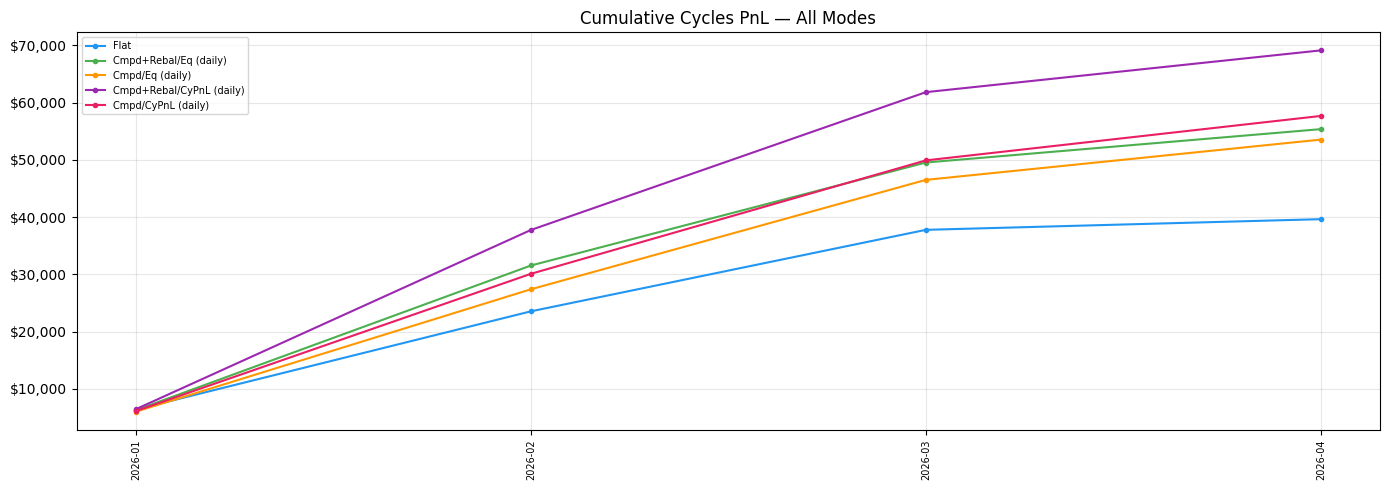

In [11]:
# Cumulative cycles PnL — all modes
fig, ax = plt.subplots(figsize=(14, 5))
for (label, _, _, _), color in zip(ALL_MODES, MODE_COLORS):
    snap = mode_snap_m[label]
    ax.plot(snap['period'], snap['cycles_pnl'].cumsum(),
            marker='o', ms=3, lw=1.5, color=color, label=label)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Cumulative Cycles PnL — All Modes')
ax.legend(fontsize=7)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

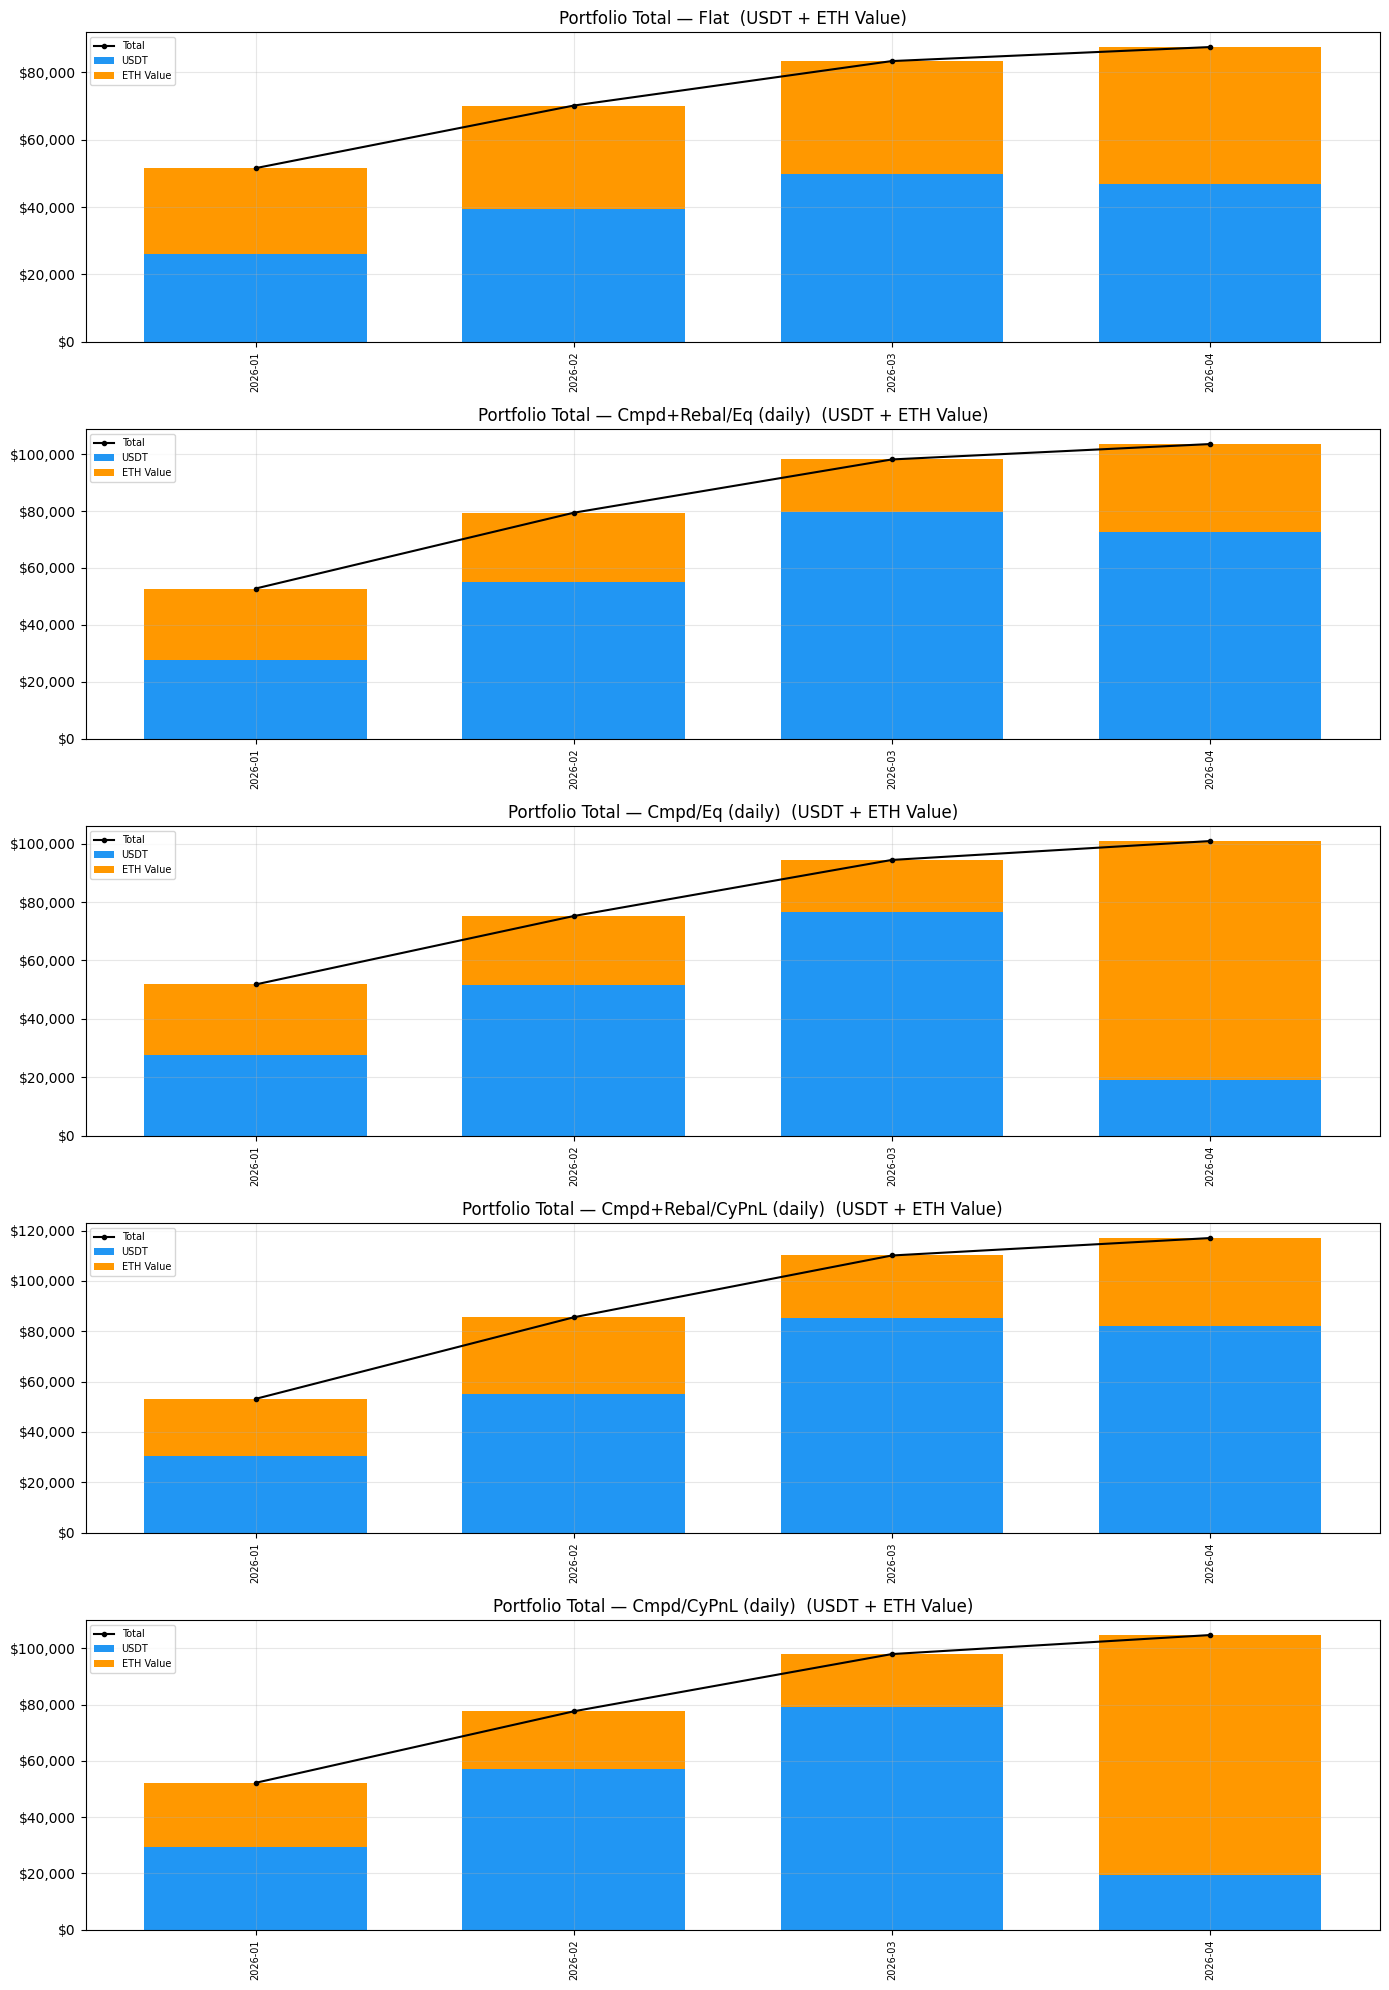

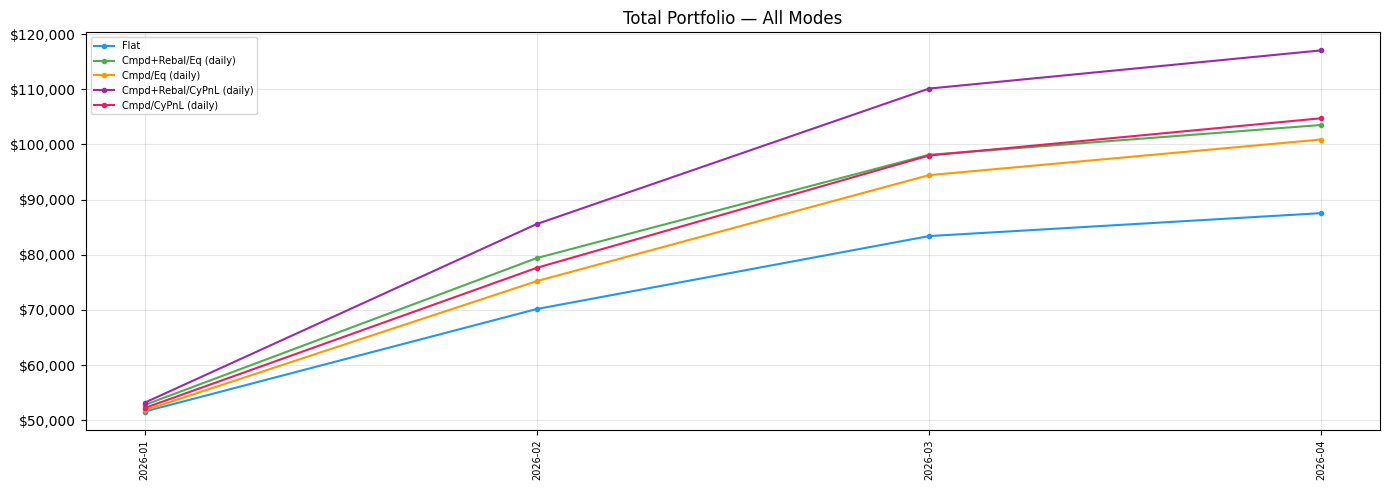

In [12]:
# Total equity over time — stacked USDT + ETH value, all modes
n_modes = len(ALL_MODES)
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 4 * n_modes))
if n_modes == 1:
    axes = [axes]

for ax, (label, _, _, _) in zip(axes, ALL_MODES):
    df_s = mode_snap_m[label]
    months = df_s['period']
    x      = range(len(months))
    ax.bar(x, df_s['usdt'],      color='#2196F3', width=0.7, label='USDT')
    ax.bar(x, df_s['eth_value'], color='#FF9800', width=0.7,
           bottom=df_s['usdt'], label='ETH Value')
    ax.plot(x, df_s['total'], color='black', linewidth=1.5,
            marker='o', markersize=3, label='Total')
    ax.set_xticks(list(x))
    ax.set_xticklabels(months, rotation=90, fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
    ax.set_title(f'Portfolio Total — {label}  (USDT + ETH Value)')
    ax.legend(loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

# All modes total on same chart
fig, ax = plt.subplots(figsize=(14, 5))
for (label, _, _, _), color in zip(ALL_MODES, MODE_COLORS):
    snap = mode_snap_m[label]
    ax.plot(snap['period'], snap['total'],
            marker='o', ms=3, lw=1.5, color=color, label=label)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.set_title('Total Portfolio — All Modes')
ax.legend(fontsize=7)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

## 📈 Equity Curve — Flat vs Compounding

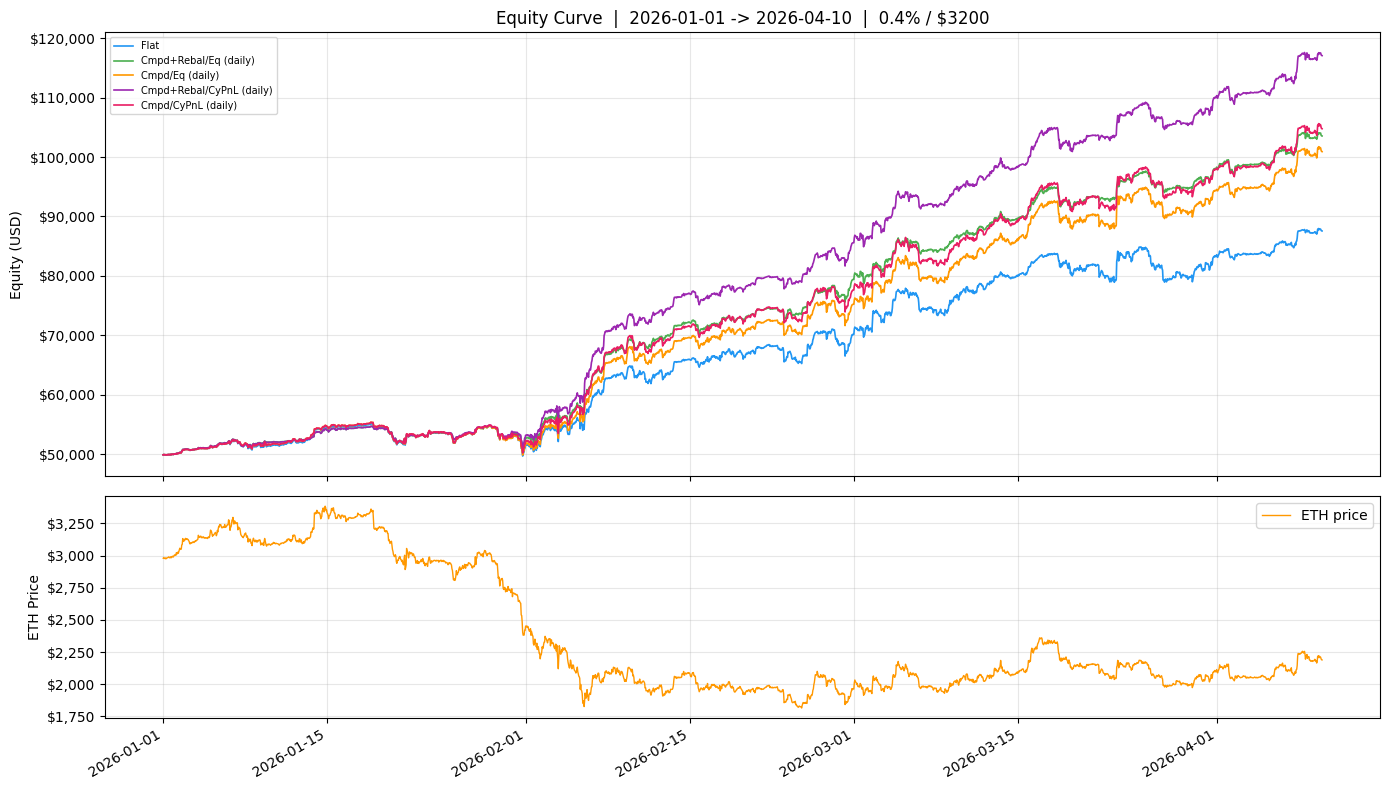

In [13]:
def eq_df(engine):
    ts  = pd.to_datetime([t for t,_ in engine.equity_curve], utc=True)
    val = [v for _,v in engine.equity_curve]
    return pd.DataFrame({'equity': val}, index=ts).resample('1h').last().dropna()

mode_eq = {label: eq_df(engines[label]) for label, _, _, _ in ALL_MODES}
df_px = df_candles.set_index('ts')['close'].resample('1h').last().dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
for (label, _, _, _), color in zip(ALL_MODES, MODE_COLORS):
    df_eq = mode_eq[label]
    ax1.plot(df_eq.index, df_eq['equity'], color=color, lw=1.2, label=label)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_ylabel('Equity (USD)')
ax1.legend(fontsize=7)
ax1.set_title(f'Equity Curve  |  {START_DATE} -> {END_DATE}  |  {UPPER_PCT}% / ${BUY_QUOTE}')
ax2.plot(df_px.index, df_px.values, color='#FF9800', lw=1, label='ETH price')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_ylabel('ETH Price')
ax2.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 💰 Monthly PnL — Flat vs Compounding

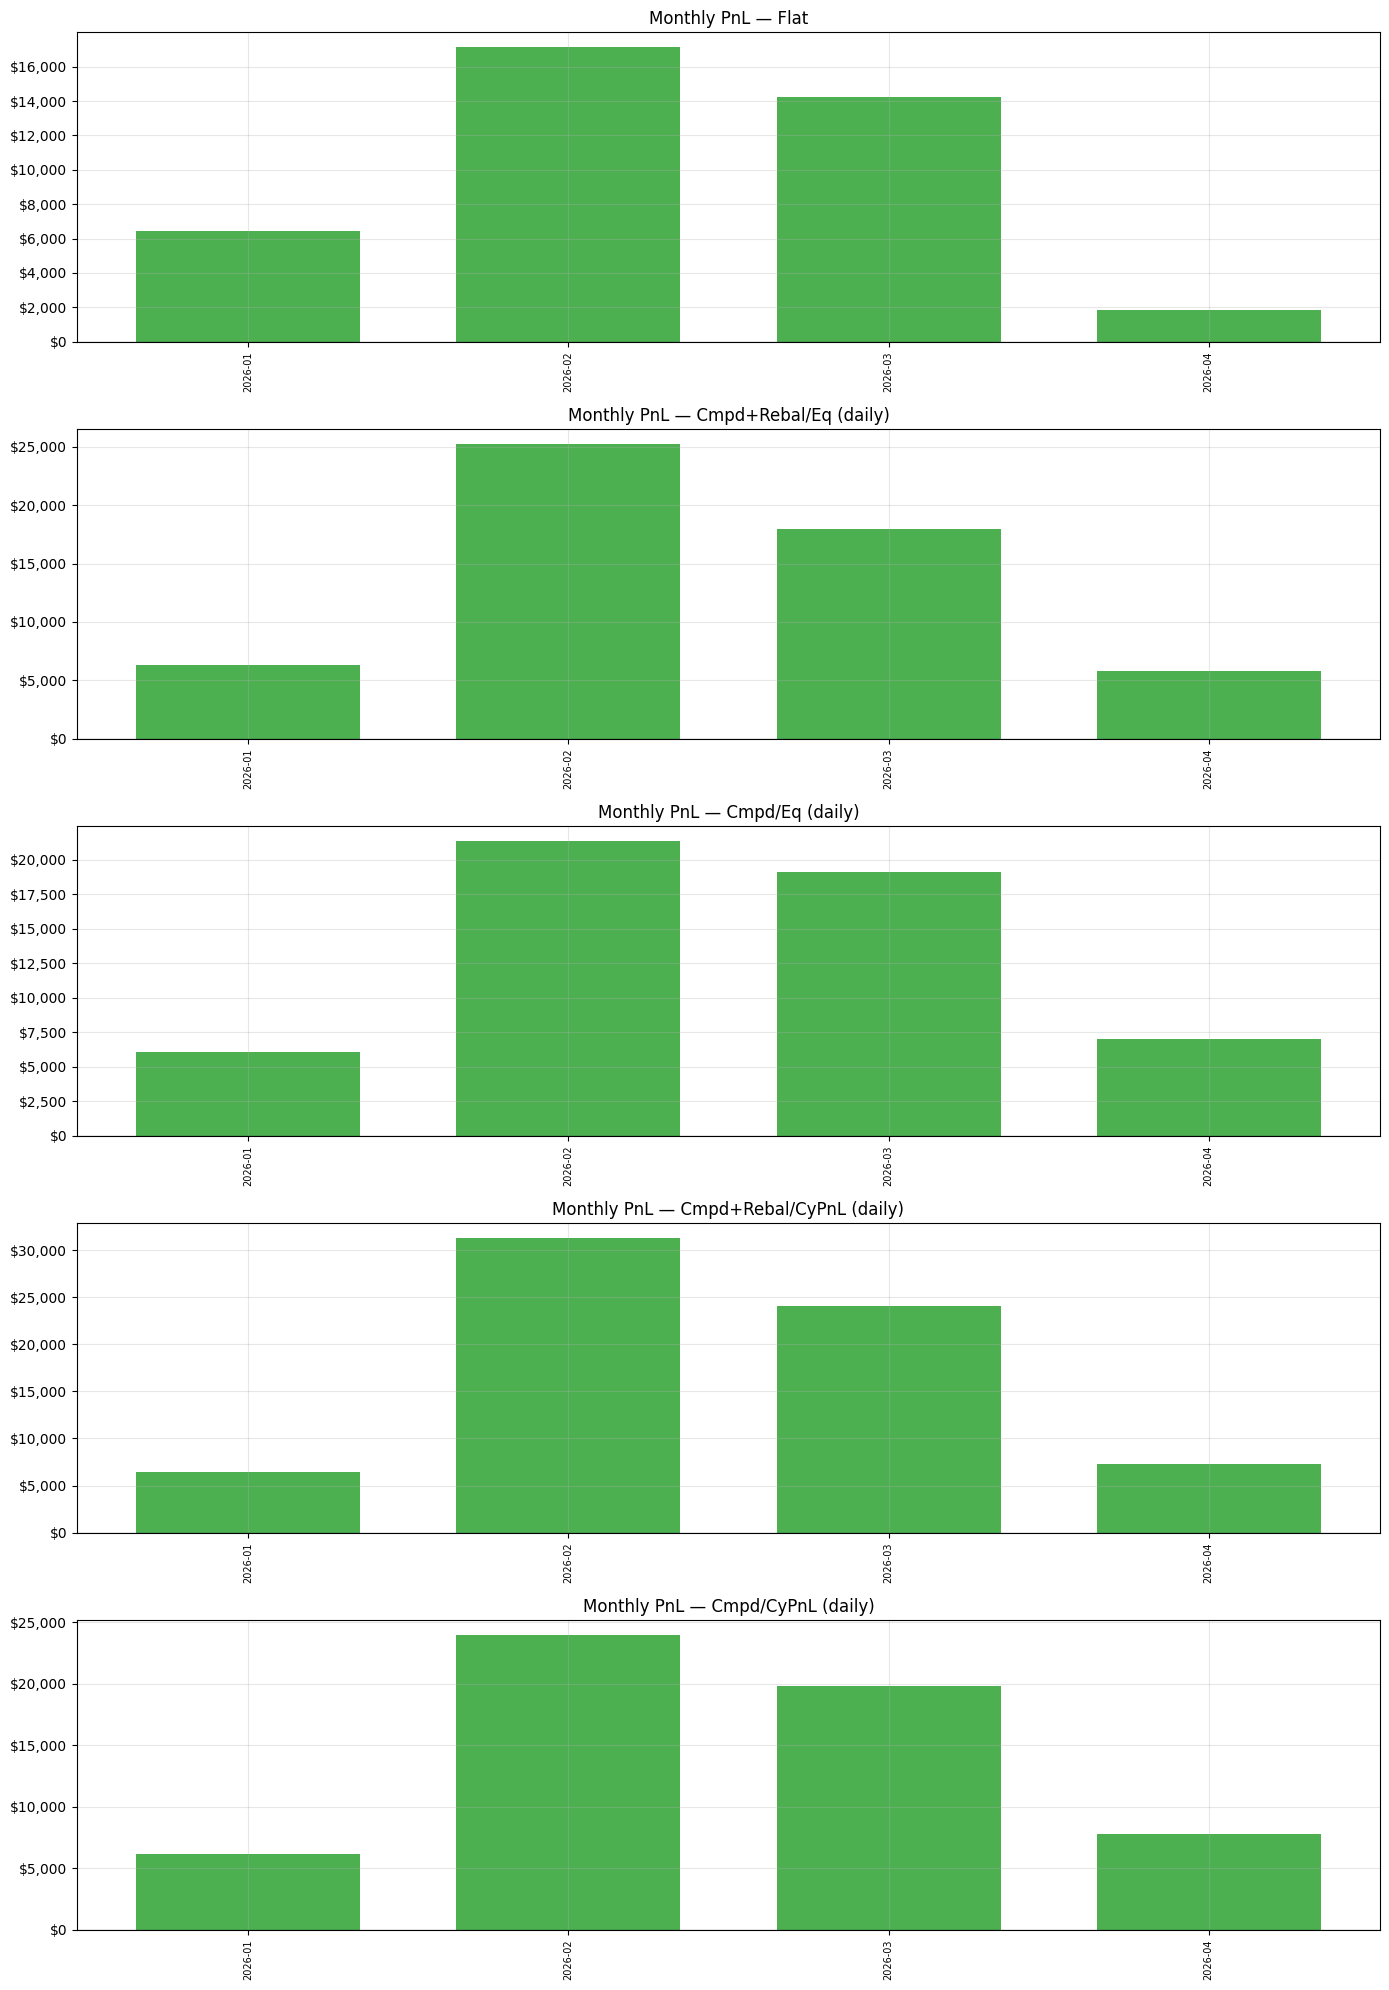

In [14]:
n_modes = len(ALL_MODES)
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 4 * n_modes))
if n_modes == 1:
    axes = [axes]

for ax, (label, _, _, _) in zip(axes, ALL_MODES):
    df_m = mode_monthly[label]
    colors = ['#4CAF50' if v >= 0 else '#F44336' for v in df_m['realized_pnl']]
    ax.bar(df_m['month'], df_m['realized_pnl'], color=colors, width=0.7)
    ax.axhline(0, color='black', lw=0.8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_title(f'Monthly PnL — {label}')
    ax.tick_params(axis='x', rotation=90, labelsize=7)

plt.tight_layout()
plt.show()

## 📈 Cumulative PnL — Flat vs Compounding

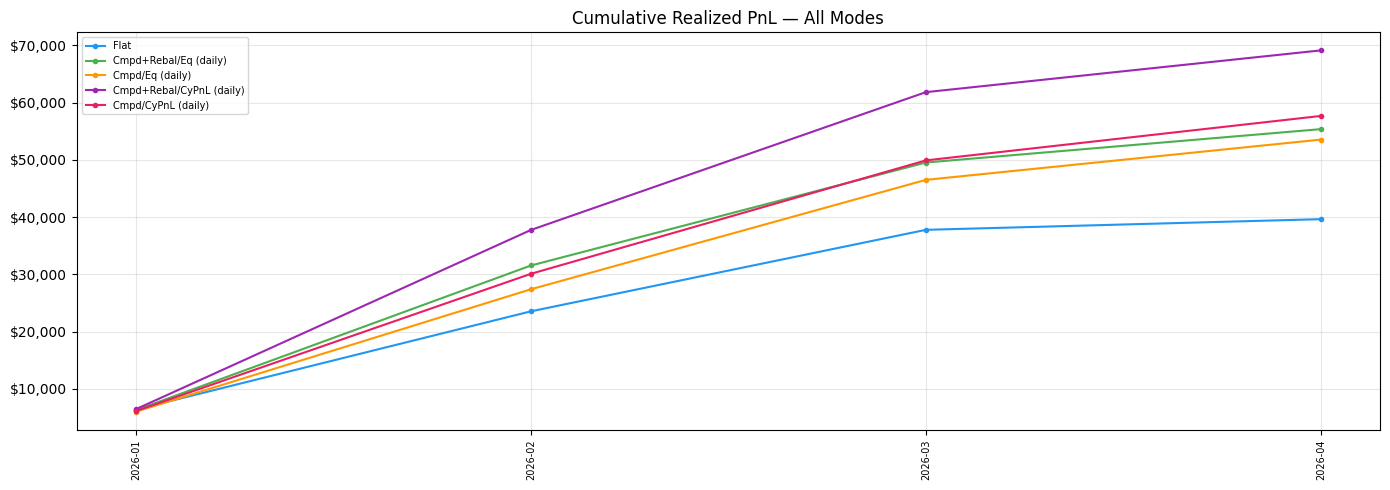

In [15]:
months = mode_monthly[ALL_MODES[0][0]]['month'].values

fig, ax = plt.subplots(figsize=(14, 5))
for (label, _, _, _), color in zip(ALL_MODES, MODE_COLORS):
    df_m = mode_monthly[label]
    cum = df_m['realized_pnl'].cumsum().values
    ax.plot(df_m['month'].values[:len(cum)], cum,
            marker='o', ms=3, lw=1.5, color=color, label=label)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Cumulative Realized PnL — All Modes')
ax.legend(fontsize=7)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

## 📐 Step Size History (Compounding)

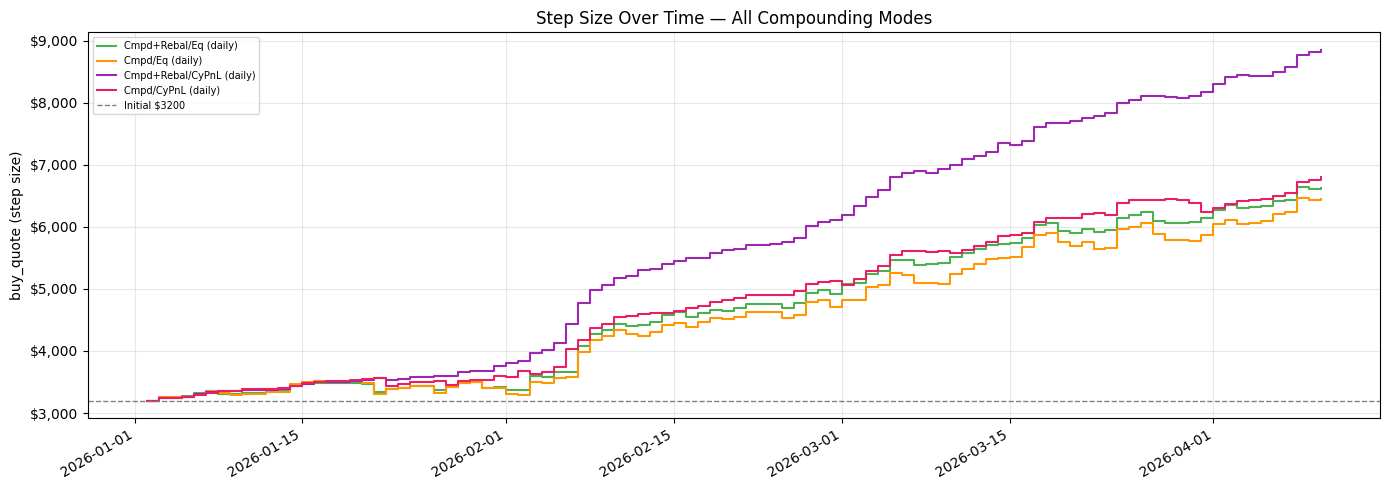


Step size (Cmpd+Rebal/Eq (daily)): $3,200 -> $6,626.06  (99 adjustments)


ts,equity,compound_equity,cum_cycle_pnl,old_quote,new_quote,eth_before,eth_after,eth_target
2026-03-30 00:00:00+00:00,"$95,049.47","$95,049.47","$64,557.09","$6,056.48","$6,083.17",23.3995,14.3547,14.3547
2026-03-31 00:00:00+00:00,"$95,932.19","$95,932.19","$65,467.16","$6,083.17","$6,139.66",26.5609,14.2074,14.2074
2026-04-01 00:00:00+00:00,"$98,113.67","$98,113.67","$66,805.82","$6,139.66","$6,279.27",13.9889,13.9889,13.9889
2026-04-02 00:00:00+00:00,"$99,305.67","$99,305.67","$68,091.98","$6,279.27","$6,355.56",14.5479,13.9268,13.9268
2026-04-03 00:00:00+00:00,"$98,458.34","$98,458.34","$68,885.34","$6,355.56","$6,301.33",26.0395,14.3613,14.3613
2026-04-04 00:00:00+00:00,"$98,749.55","$98,749.55","$68,693.39","$6,301.33","$6,319.97",14.4301,14.4301,14.4301
2026-04-05 00:00:00+00:00,"$99,070.18","$99,070.18","$68,907.11","$6,319.97","$6,340.49",14.3927,14.3927,14.3927
2026-04-06 00:00:00+00:00,"$100,296.50","$100,296.50","$69,692.44","$6,340.49","$6,418.98",14.2144,14.2144,14.2144
2026-04-07 00:00:00+00:00,"$100,600.77","$100,600.77","$70,589.15","$6,418.98","$6,438.45",23.8102,14.3152,14.3152
2026-04-08 00:00:00+00:00,"$103,731.83","$103,731.83","$72,696.25","$6,438.45","$6,638.84",13.8656,13.8656,13.8656


In [16]:
# Step size history — all compounding modes (skip Flat)
compound_modes = [(label, color) for (label, ci, _, _), color in zip(ALL_MODES, MODE_COLORS) if ci is not None]

if compound_modes:
    fig, ax = plt.subplots(figsize=(14, 5))
    for label, color in compound_modes:
        eng = engines[label]
        if eng.compound_log:
            df_cl = pd.DataFrame(eng.compound_log)
            df_cl['ts'] = pd.to_datetime(df_cl['ts'], utc=True, errors='coerce')
            ax.step(df_cl['ts'], df_cl['new_quote'], where='post', color=color, lw=1.5, label=label)
    ax.axhline(BUY_QUOTE, color='gray', ls='--', lw=1, label=f'Initial ${BUY_QUOTE}')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_ylabel('buy_quote (step size)')
    ax.set_title('Step Size Over Time — All Compounding Modes')
    ax.legend(fontsize=7)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    # Detailed table for primary compound mode
    label0 = compound_modes[0][0]
    eng0 = engines[label0]
    if eng0.compound_log:
        df_cl0 = pd.DataFrame(eng0.compound_log)
        df_cl0['ts'] = pd.to_datetime(df_cl0['ts'], utc=True, errors='coerce')
        print(f'\nStep size ({label0}): ${BUY_QUOTE:,} -> ${df_cl0["new_quote"].iloc[-1]:,.2f}  ({len(df_cl0)} adjustments)')
        display(df_cl0[['ts','equity','compound_equity','cum_cycle_pnl','old_quote','new_quote','eth_before','eth_after','eth_target']].tail(12)
                .style.format({'equity':'${:,.2f}','compound_equity':'${:,.2f}','cum_cycle_pnl':'${:,.2f}',
                               'old_quote':'${:,.2f}','new_quote':'${:,.2f}',
                               'eth_before':'{:.4f}','eth_after':'{:.4f}','eth_target':'{:.4f}'})
                .hide(axis='index'))
else:
    print('No compounding modes active.')

## 📉 Drawdown — Flat vs Compounding

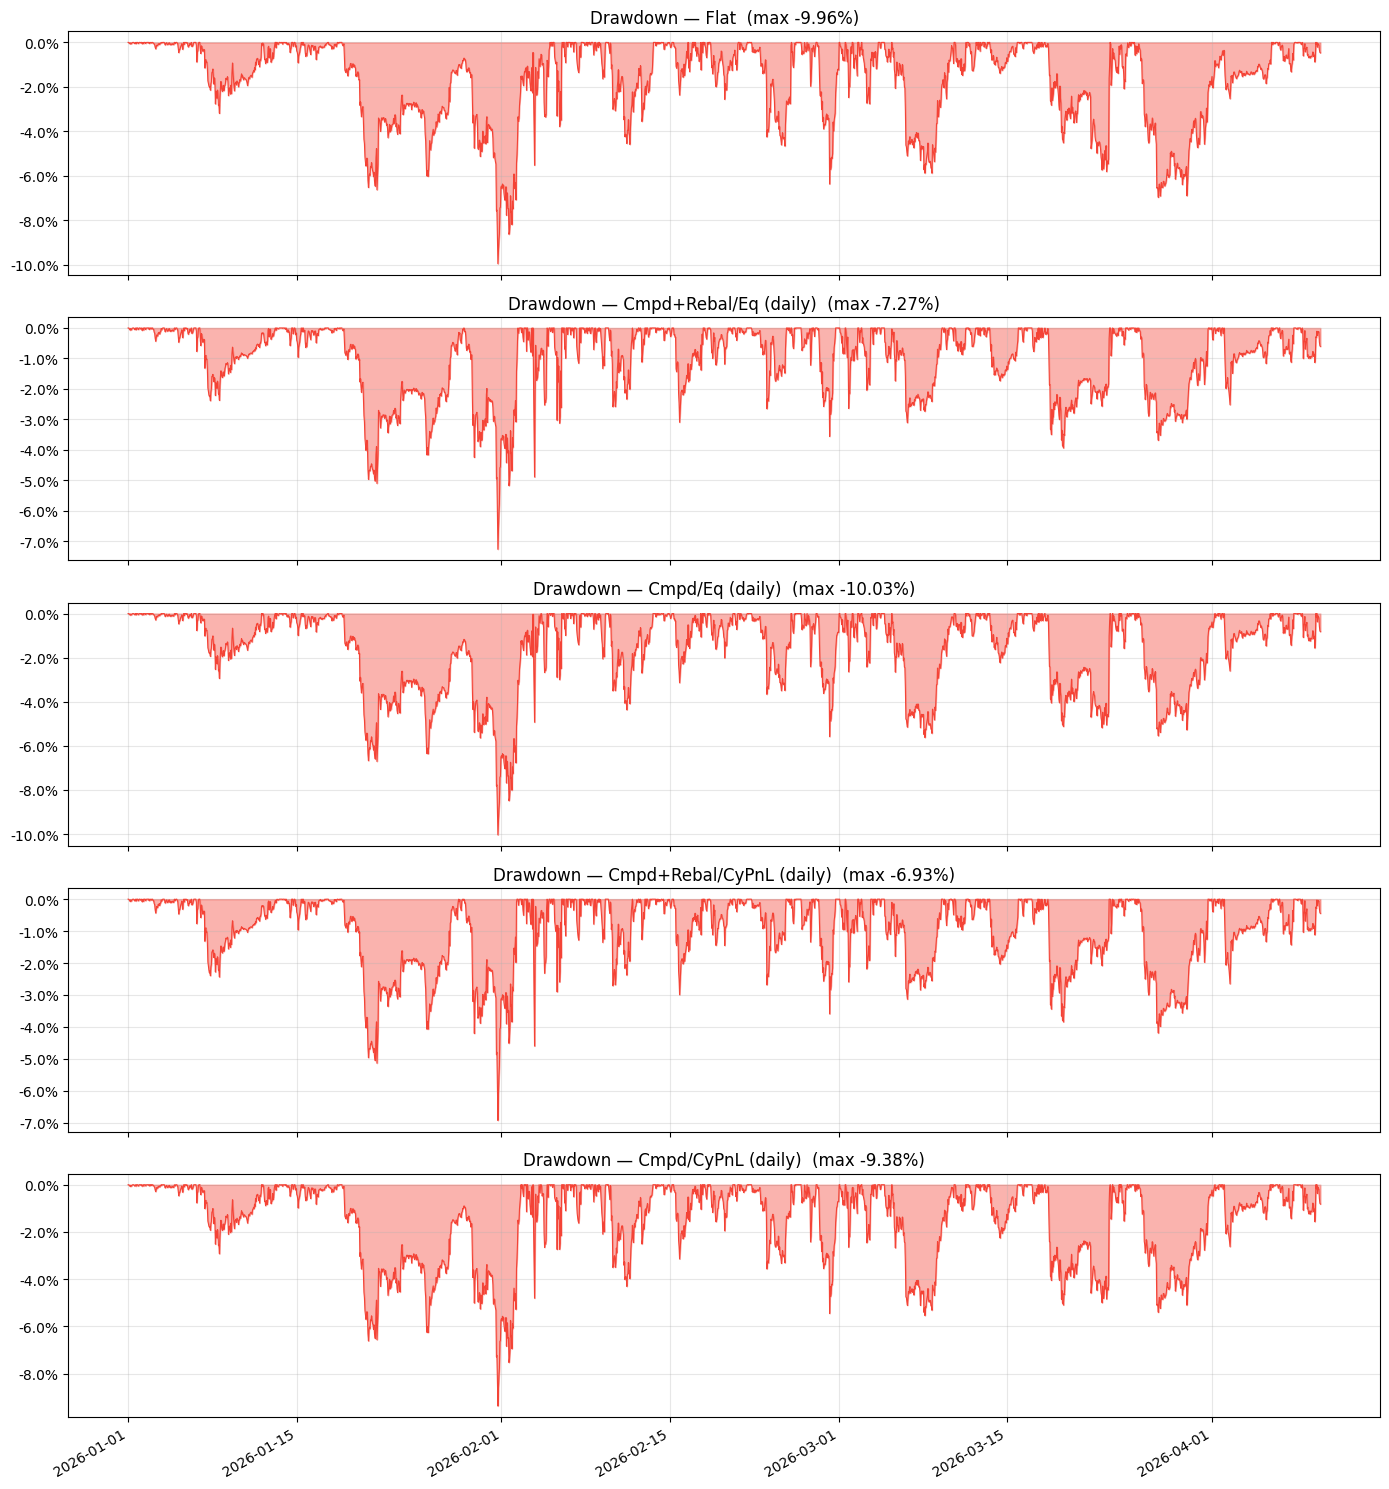

In [17]:
n_modes = len(ALL_MODES)
fig, axes = plt.subplots(n_modes, 1, figsize=(14, 3 * n_modes), sharex=True)
if n_modes == 1:
    axes = [axes]

for ax, (label, _, _, _), color in zip(axes, ALL_MODES, MODE_COLORS):
    df_eq = mode_eq[label]
    peak = df_eq['equity'].cummax()
    dd   = (df_eq['equity'] - peak) / peak * 100
    ax.fill_between(dd.index, dd.values, 0, color='#F44336', alpha=0.4)
    ax.plot(dd.index, dd.values, color='#F44336', lw=0.8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    ax.set_title(f'Drawdown — {label}  (max {dd.min():.2f}%)')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 🔄 Config Comparison — Flat vs Compounding

In [18]:
COMPARE_CONFIGS = [
    dict(label='0.4% / $1400', upper_pct=0.4, lower_pct=0.4, buy_quote=1400, sell_quote=1400),
    dict(label='0.6% / $1500', upper_pct=0.6, lower_pct=0.6, buy_quote=1500, sell_quote=1500),
    dict(label='0.5% / $1000', upper_pct=0.5, lower_pct=0.5, buy_quote=1000, sell_quote=1000),
    dict(label='1.0% / $2000', upper_pct=1.0, lower_pct=1.0, buy_quote=2000, sell_quote=2000),
]

print(f'Fetching {COMPARE_INTERVAL} candles for comparison...')
df_cmp_candles = fetch_klines(
    symbol=FETCH_SYMBOL, interval=COMPARE_INTERVAL,
    start_ms=dt_to_ms(START_DATE), end_ms=dt_to_ms(END_DATE),
    cache_dir=CACHE_DIR, source=DATA_SOURCE,
)
cmp_candles = df_cmp_candles.to_dict('records')
print(f'Comparison candles: {len(cmp_candles):,}')

# All 5 modes for config comparison
CMP_MODES = [
    (None,              True,  'equity',    'Flat'),
    (COMPOUND_INTERVAL, True,  'equity',    f'Cmpd+Rebal/Eq'),
    (COMPOUND_INTERVAL, False, 'equity',    f'Cmpd/Eq'),
    (COMPOUND_INTERVAL, True,  'cycle_pnl', f'Cmpd+Rebal/CyPnL'),
    (COMPOUND_INTERVAL, False, 'cycle_pnl', f'Cmpd/CyPnL'),
]
CMP_COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#E91E63']

print(f'Sizing mode: {SIZING_MODE}  |  band_width: {BAND_WIDTH}  |  max_buy_quote: ${MAX_BUY_QUOTE:,}')
results = []
for cfg in COMPARE_CONFIGS:
    for compound, rebal_eth, basis, mode_label in CMP_MODES:
        scfg = dict(symbols=[SYMBOL], sizing_mode=SIZING_MODE, band_width=BAND_WIDTH,
                    qty_step=QTY_STEP, min_qty=MIN_QTY,
                    rebalance_threshold_steps=REBALANCE_THRESHOLD_STEPS,
                    rebalance_target_steps=REBALANCE_TARGET_STEPS,
                    **{k: v for k, v in cfg.items() if k != 'label'})
        eng = BacktestEngine(
            strategy=create_strategy(scfg), symbol=SYMBOL,
            initial_cash=Decimal(str(INITIAL_CASH)), initial_eth=Decimal(str(INITIAL_ETH)),
            initial_eth_cost=Decimal(str(INITIAL_ETH_COST)), quote_reserve=Decimal(str(QUOTE_RESERVE)),
            use_inventory_buffer=USE_INVENTORY_BUFFER, compound_interval=compound,
            compound_rebalance_eth=rebal_eth, compound_basis=basis,
            max_buy_quote=Decimal(str(MAX_BUY_QUOTE)),
        )
        s = eng.run(cmp_candles)
        results.append({
            'Config': cfg['label'], 'Mode': mode_label,
            'Realized PnL':  round(s['realized_pnl'], 2),
            'Final Equity':  round(s['final_equity'], 2),
            'Annualised%':   round(((s['final_equity'] / s['initial_equity']) ** (365 / days) - 1) * 100, 1) if days else 0,
            'Cycles':        s['cycles'],
            'Avg PnL/Cycle': round(s['realized_pnl'] / s['cycles'], 2) if s['cycles'] else 0,
            'Max DD%':       s['max_drawdown_pct'],
        })
        print(f"  {cfg['label']:20s}  [{mode_label:20s}]  cycles={s['cycles']:,}  pnl=${s['realized_pnl']:,.0f}")

df_cmp = pd.DataFrame(results)
df_cmp.style\
    .format({'Realized PnL': '${:,.2f}', 'Final Equity': '${:,.2f}',
             'Annualised%': '{:.1f}%', 'Avg PnL/Cycle': '${:.2f}', 'Max DD%': '{:.2f}%'})\
    .highlight_max(subset=['Realized PnL', 'Annualised%'], color='#c8e6c9')\
    .highlight_min(subset=['Max DD%'], color='#c8e6c9')\
    .hide(axis='index')

Fetching 1m candles for comparison...
[fetch_data] Loading cached data from cache/binance_ETHUSDT_1m_1767225600000_1775779200000.parquet
Comparison candles: 142,561
Sizing mode: banded_qty  |  band_width: 100  |  max_buy_quote: $10,000
  0.4% / $1400          [Flat                ]  cycles=4,506  pnl=$17,864
  0.4% / $1400          [Cmpd+Rebal/Eq       ]  cycles=4,510  pnl=$14,845
  0.4% / $1400          [Cmpd/Eq             ]  cycles=4,498  pnl=$15,586
  0.4% / $1400          [Cmpd+Rebal/CyPnL    ]  cycles=4,509  pnl=$18,257
  0.4% / $1400          [Cmpd/CyPnL          ]  cycles=4,501  pnl=$18,611
  0.6% / $1500          [Flat                ]  cycles=2,013  pnl=$9,205
  0.6% / $1500          [Cmpd+Rebal/Eq       ]  cycles=2,021  pnl=$6,763
  0.6% / $1500          [Cmpd/Eq             ]  cycles=2,013  pnl=$11,767
  0.6% / $1500          [Cmpd+Rebal/CyPnL    ]  cycles=2,022  pnl=$8,445
  0.6% / $1500          [Cmpd/CyPnL          ]  cycles=2,012  pnl=$9,581
  0.5% / $1000          [Fla

Config,Mode,Realized PnL,Final Equity,Annualised%,Cycles,Avg PnL/Cycle,Max DD%
0.4% / $1400,Flat,"$17,863.55","$65,259.76",169.8%,4506,$3.96,22.71%
0.4% / $1400,Cmpd+Rebal/Eq,"$14,845.36","$63,751.70",147.5%,4510,$3.29,13.22%
0.4% / $1400,Cmpd/Eq,"$15,585.97","$63,450.37",143.2%,4498,$3.47,24.17%
0.4% / $1400,Cmpd+Rebal/CyPnL,"$18,257.23","$67,116.69",199.2%,4509,$4.05,13.44%
0.4% / $1400,Cmpd/CyPnL,"$18,610.86","$66,535.76",189.7%,4501,$4.13,21.20%
0.6% / $1500,Flat,"$9,205.03","$57,176.80",65.7%,2013,$4.57,26.35%
0.6% / $1500,Cmpd+Rebal/Eq,"$6,763.50","$55,793.63",51.4%,2021,$3.35,13.19%
0.6% / $1500,Cmpd/Eq,"$11,767.17","$55,608.93",49.5%,2013,$5.85,27.95%
0.6% / $1500,Cmpd+Rebal/CyPnL,"$8,445.09","$57,316.95",67.2%,2022,$4.18,13.34%
0.6% / $1500,Cmpd/CyPnL,"$9,580.57","$57,733.05",71.7%,2012,$4.76,25.67%


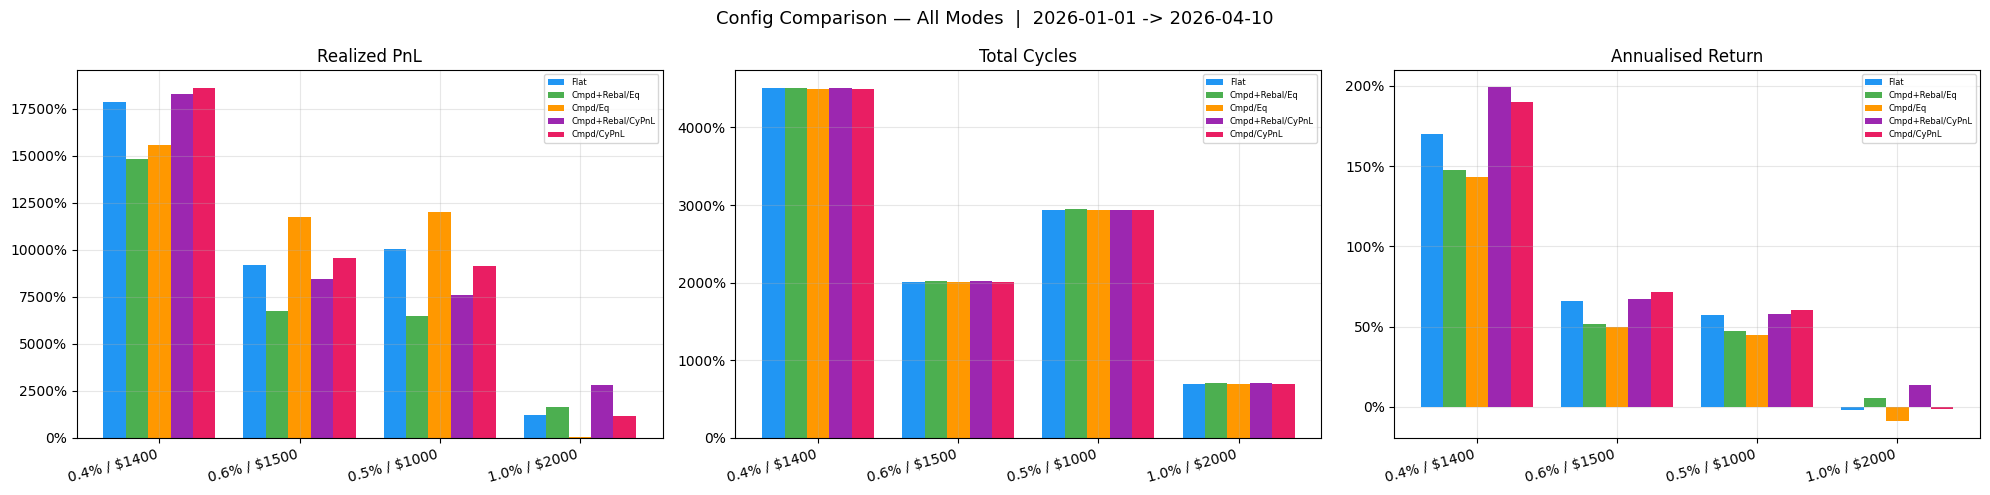

In [19]:
configs   = df_cmp['Config'].unique()
cmp_modes = df_cmp['Mode'].unique()
x         = range(len(configs))
n_modes   = len(cmp_modes)
w         = 0.8 / n_modes

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, col, title, fmt_fn in [
    (axes[0], 'Realized PnL',  'Realized PnL',     lambda v: f'${v:,.0f}'),
    (axes[1], 'Cycles',        'Total Cycles',      lambda v: f'{v:,.0f}'),
    (axes[2], 'Annualised%',   'Annualised Return', lambda v: f'{v:.0f}%'),
]:
    for j, (mode, color) in enumerate(zip(cmp_modes, CMP_COLORS)):
        df_mode = df_cmp[df_cmp['Mode'] == mode]
        offset  = (j - n_modes / 2 + 0.5) * w
        ax.bar([i + offset for i in x], df_mode[col], w, label=mode, color=color)
    ax.set_xticks(list(x))
    ax.set_xticklabels(configs, rotation=15, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt_fn(v)))
    ax.set_title(title)
    ax.legend(fontsize=6)

plt.suptitle(f'Config Comparison — All Modes  |  {START_DATE} -> {END_DATE}', fontsize=13)
plt.tight_layout()
plt.show()